# FX Carry Project — Data Visualization & Summary Statistics

Exploratory overview of the Bloomberg dataset (daily, 2007-01 → 2026-07) that will feed the FX carry strategy (CIP/UIP).

**Contents**
1. Data loading & coverage
2. Currency panel construction (conventions, forwards, implied carry)
3. Time-series visualization (spots, carry, excess returns, vols, rates, risk factors)
4. Summary statistics (moments, Sharpe, IR, drawdowns, VaR/CVaR)
5. What drives returns — factor regressions (LRV `DOL`/`HML_FX` + macro factors)
6. Data gaps & Bloomberg additions (now resolved)
7. CIP basis check (forward-implied carry vs onshore rates)
8. UIP / Fama regressions
9. Notes & next steps

Shared logic lives in [`cesare/fx_utils.py`](fx_utils.py) so the future strategy notebooks reuse the exact same return construction.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(".")
import fx_utils as fx

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40)
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)


def ts_grid(df, ncols=4, title="", height=1.9, zero_line=False):
    """Small-multiples line plot, one panel per column."""
    cols = [c for c in df.columns if df[c].notna().any()]
    nrows = -(-len(cols) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, height * nrows), sharex=True)
    for ax, c in zip(np.ravel(axes), cols):
        ax.plot(df.index, df[c], lw=0.7)
        if zero_line:
            ax.axhline(0, color="grey", lw=0.6, ls="--")
        ax.set_title(c, fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, y=1.0, fontsize=13)
    fig.tight_layout()
    plt.show()

## 1. Data loading & coverage

Wide parquets, `PX_LAST` only (bid/ask exist for FX & options — kept for later transaction-cost work).

In [2]:
GROUPS = ["g10_fx_spot_forward", "em_fx_spot_forward", "g10_fx_options", "em_fx_options",
          "g10_interest_rates", "em_interest_rates", "global_risk", "macro_market_proxies",
          # Phase-2 supplemental groups (hand-pulled Bloomberg, converted from
          # data/raw/FX_extra_data.xlsx by src/convert_extra_xlsx.py)
          "usd_riskfree", "fx_carry_benchmarks", "g10_rates_gaps", "em_onshore_rates", "em_risk"]
data = {g: fx.load_wide(g) for g in GROUPS}

coverage = pd.DataFrame({g: {"tickers": d.shape[1], "days": d.shape[0],
                             "start": d.index.min().date(), "end": d.index.max().date(),
                             "non_nan_%": round(100 * d.notna().mean().mean(), 1)}
                         for g, d in data.items()}).T
coverage

,tickers,days,start,end,non_nan_%
g10_fx_spot_forward,66,5087,2007-01-01,2026-06-30,100.0
em_fx_spot_forward,95,5094,2007-01-01,2026-06-30,95.9
g10_fx_options,275,5087,2007-01-01,2026-06-30,99.3
em_fx_options,325,5087,2007-01-01,2026-06-30,97.7
g10_interest_rates,81,5087,2007-01-01,2026-06-30,88.8
em_interest_rates,34,5087,2007-01-01,2026-06-30,77.7
global_risk,19,5087,2007-01-01,2026-06-30,98.5
macro_market_proxies,24,5155,2007-01-01,2026-06-30,79.7
usd_riskfree,1,5091,2007-01-01,2026-07-06,100.0
fx_carry_benchmarks,3,5091,2007-01-01,2026-07-06,100.0


## 2. Currency panel construction

**Conventions.** Bloomberg quotes EUR/GBP/AUD/NZD as USD-per-FX (`EUR Curncy` = EURUSD) and everything else as FX-per-USD (`JPY Curncy` = USDJPY). Every spot is re-expressed as **USD per unit of foreign currency**, so a positive return always means the foreign currency appreciated vs USD.

**Forward-implied carry (CIP).** Covered interest parity ties the forward to the interest differential, $F/S=(1+r_{fx})/(1+r_{usd})$ in FX-per-USD terms, so the annualised $\ln(S/F)$ (USD-per-FX terms) is the **carry earned by buying the currency forward** — no onshore rate data needed. Under UIP that carry would be offset by depreciation; the carry trade is the bet that it isn't (see the two papers in `papers/`).

**Excess returns.** Daily $\Delta\ln S$ plus the previous day's annualised 1M carry accrued over 1/252 — the standard academic approximation (roll timing and transaction costs ignored for now). Currencies use NDF forwards where outrights don't trade (BRL, CLP, COP, IDR, INR, KRW, PEN); CNY has no forwards downloaded (CNH covers offshore RMB), so CNY appears in spot stats only.

**Forward-point scales** differ by currency on Bloomberg (1e-4 pips for most, 1e-2 for JPY/HUF/INR/THB, outright units for several EM NDFs). The table below is the validation: with the scale map in `fx_utils.FWD_SCALE`, each currency's median implied 12M carry should look like its typical rate differential vs USD (JPY/CHF negative, BRL/TRY/ZAR/MXN high positive...). If a scale were wrong by 10×, the number would be absurd.

In [3]:
g10_fx, em_fx = data["g10_fx_spot_forward"], data["em_fx_spot_forward"]

spots = fx.spots_usd_per_fx(g10_fx, em_fx)
carry_1m = fx.carry_panel(g10_fx, em_fx, "1M")
carry_12m = fx.carry_panel(g10_fx, em_fx, "12M")
spot_ret = fx.spot_log_returns(spots)
xret = fx.excess_returns(spots, carry_1m)

validation = pd.DataFrame({
    "fwd_scale": pd.Series({c: fx.FWD_SCALE[c] for c in carry_12m.columns}),
    "median_impl_carry_12M_%": carry_12m.median() * 100,
    "p5_%": carry_12m.quantile(0.05) * 100,
    "p95_%": carry_12m.quantile(0.95) * 100,
}).round(2)
validation.to_csv(OUT / "implied_carry_validation.csv")
print(f"{spots.shape[1]} currencies, {xret.shape[1]} with carry excess returns")
validation.T

30 currencies, 29 with carry excess returns


,AUD,CAD,CHF,DKK,EUR,GBP,HKD,JPY,NOK,NZD,SEK,BRL,CLP,CNH,COP,HUF,IDR,ILS,INR,KRW,MXN,MYR,PEN,PHP,PLN,SGD,THB,TRY,ZAR
fwd_scale,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,100.00,10000.00,10000.00,10000.00,10000.00,1.00,10000.00,1.00,100.00,1.00,10000.00,100.00,1.00,10000.00,10000.00,10000.00,1.00,10000.00,10000.00,100.00,10000.00,10000.00
median_impl_carry_12M_%,0.88,-0.05,-1.76,-1.06,-0.88,0.08,-0.26,-1.62,0.23,1.24,-0.95,6.96,1.61,1.13,3.86,2.06,4.40,-0.70,4.14,-0.33,4.36,1.03,1.43,1.44,0.98,-0.30,0.48,11.07,4.93
p5_%,-0.90,-1.37,-4.08,-3.17,-3.03,-1.69,-0.91,-5.25,-1.46,-0.92,-2.85,2.06,-0.61,-2.57,1.55,-2.31,0.72,-2.58,1.60,-2.13,2.42,-2.03,-0.28,0.25,-0.92,-2.37,-3.03,5.32,2.87
p95_%,4.64,0.94,-0.35,1.05,0.96,1.23,0.15,-0.35,2.41,3.84,1.86,10.43,4.77,3.03,7.72,6.71,8.18,1.37,6.58,1.69,6.85,2.46,5.14,3.18,3.59,0.54,2.65,35.85,7.36


## 3. Time-series visualization

### 3.1 Spot rates (indexed to 100 at first observation, up = FX appreciates vs USD)

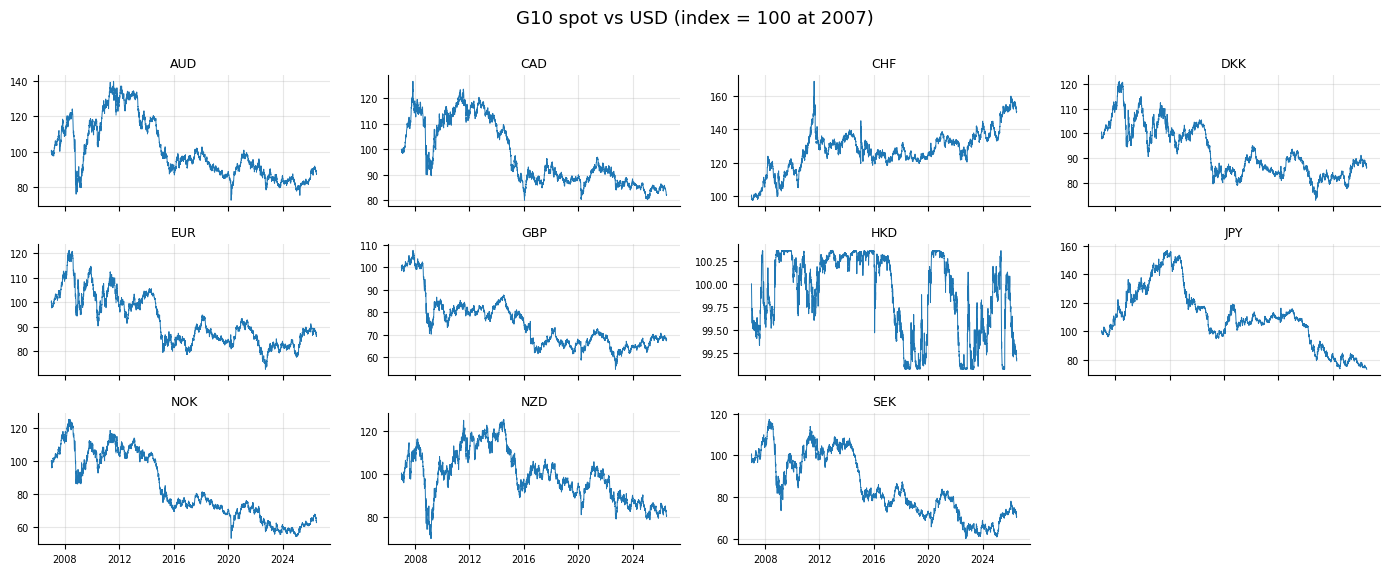

In [4]:
spot_idx = 100 * spots / spots.apply(lambda s: s.loc[s.first_valid_index()])
ts_grid(spot_idx[fx.G10], title="G10 spot vs USD (index = 100 at 2007)")

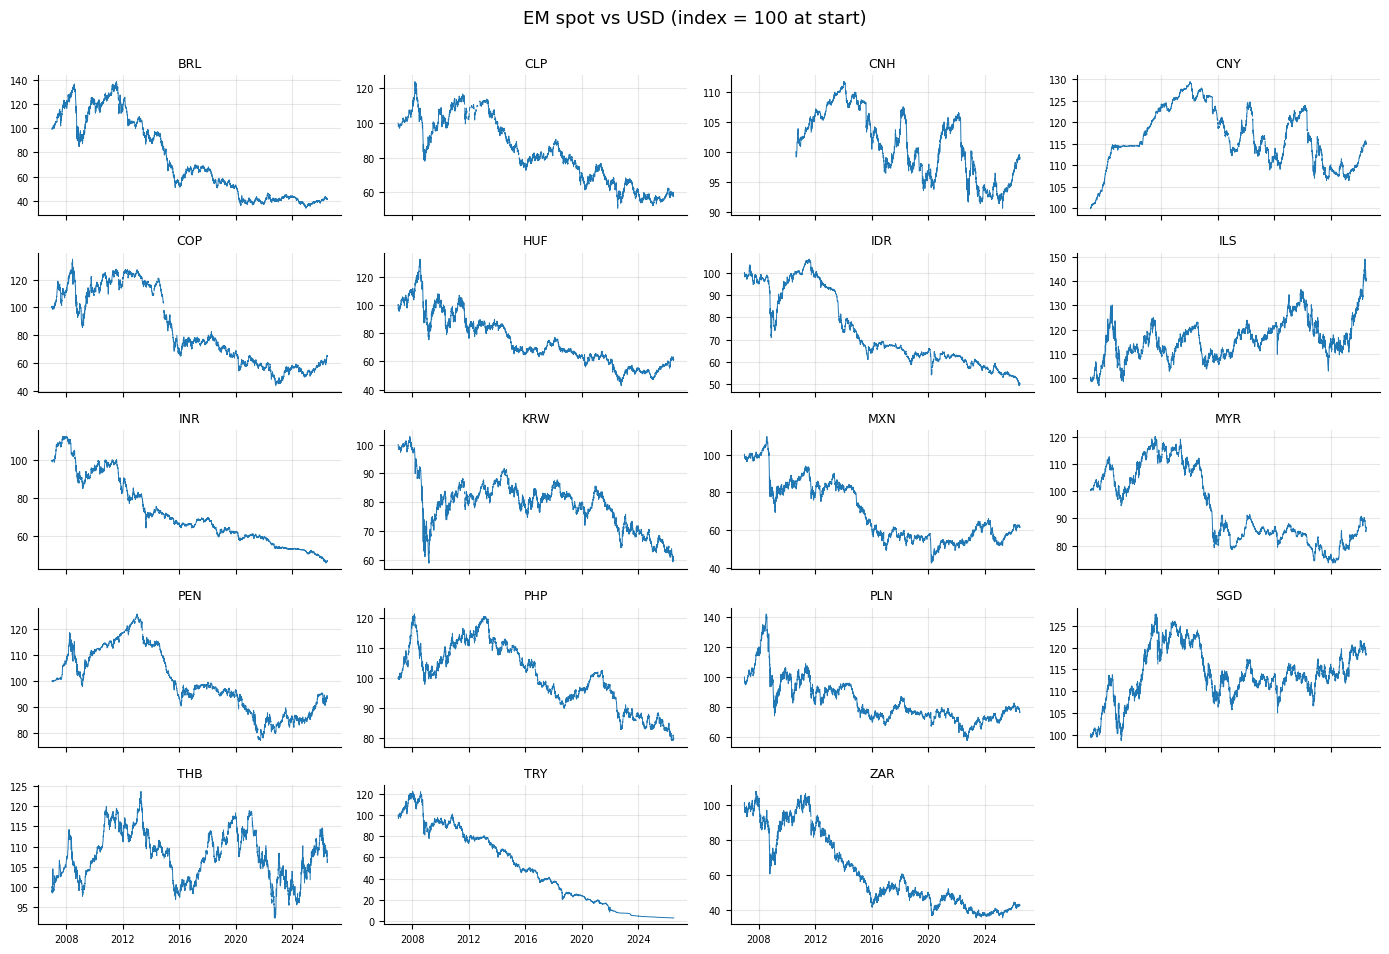

In [5]:
ts_grid(spot_idx[[c for c in fx.EM if c in spot_idx.columns]],
        title="EM spot vs USD (index = 100 at start)")

### 3.2 Forward-implied carry (annualised %, 1M tenor) — the raw material of the strategy

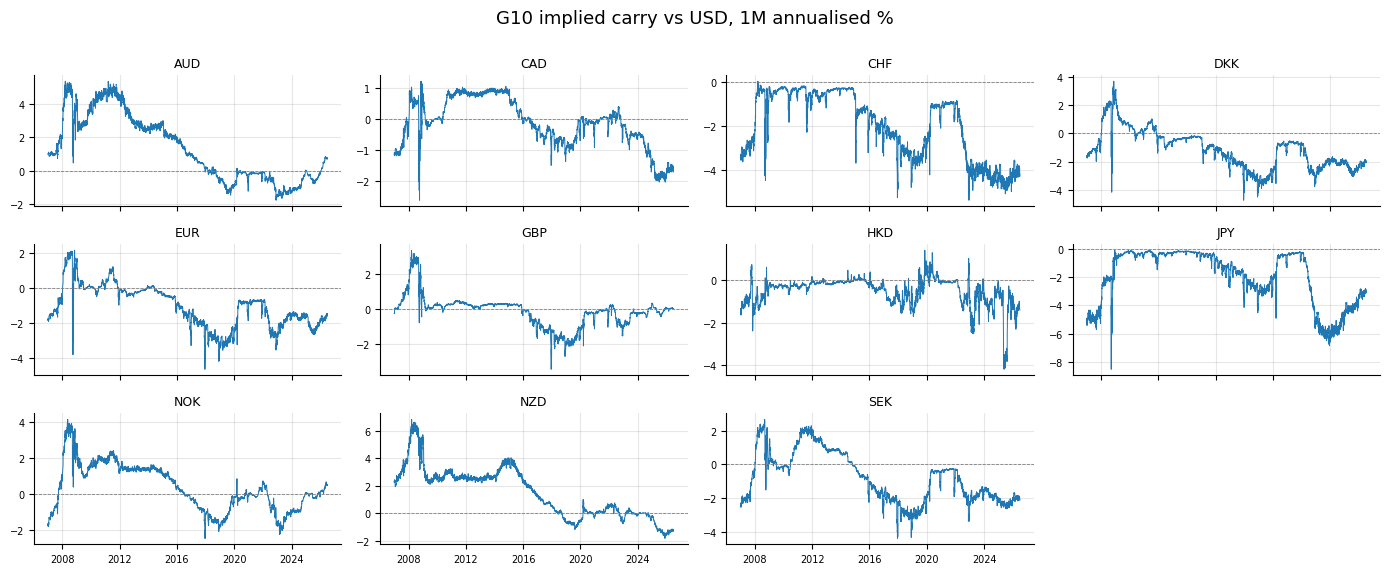

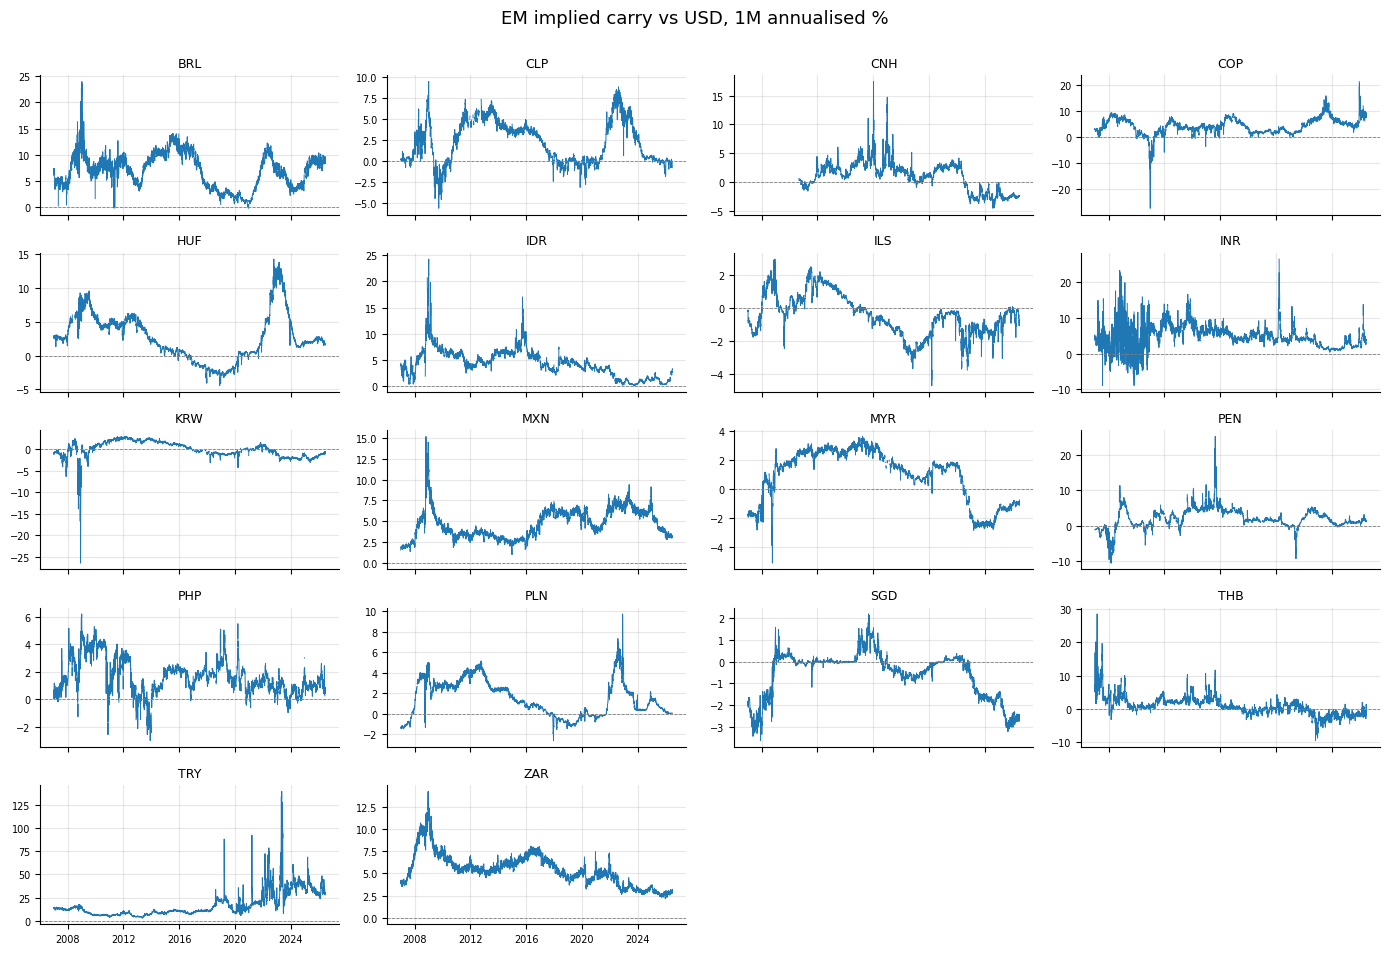

In [6]:
carry_pct = 100 * carry_1m
ts_grid(carry_pct[[c for c in fx.G10 if c in carry_pct.columns]],
        title="G10 implied carry vs USD, 1M annualised %", zero_line=True)
ts_grid(carry_pct[[c for c in fx.EM if c in carry_pct.columns]],
        title="EM implied carry vs USD, 1M annualised %", zero_line=True)

### 3.3 Cumulative carry excess returns (long FX vs USD via 1M forwards, growth of 100)

This is what a passive long position in each currency would have earned (spot + carry, before costs).

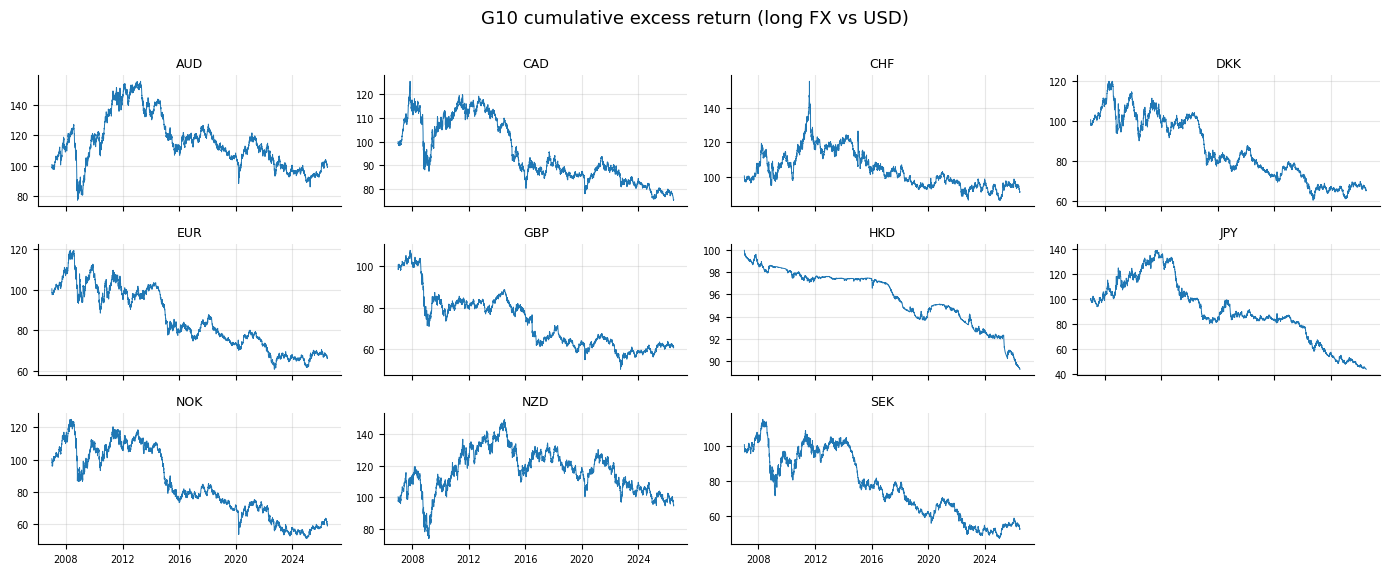

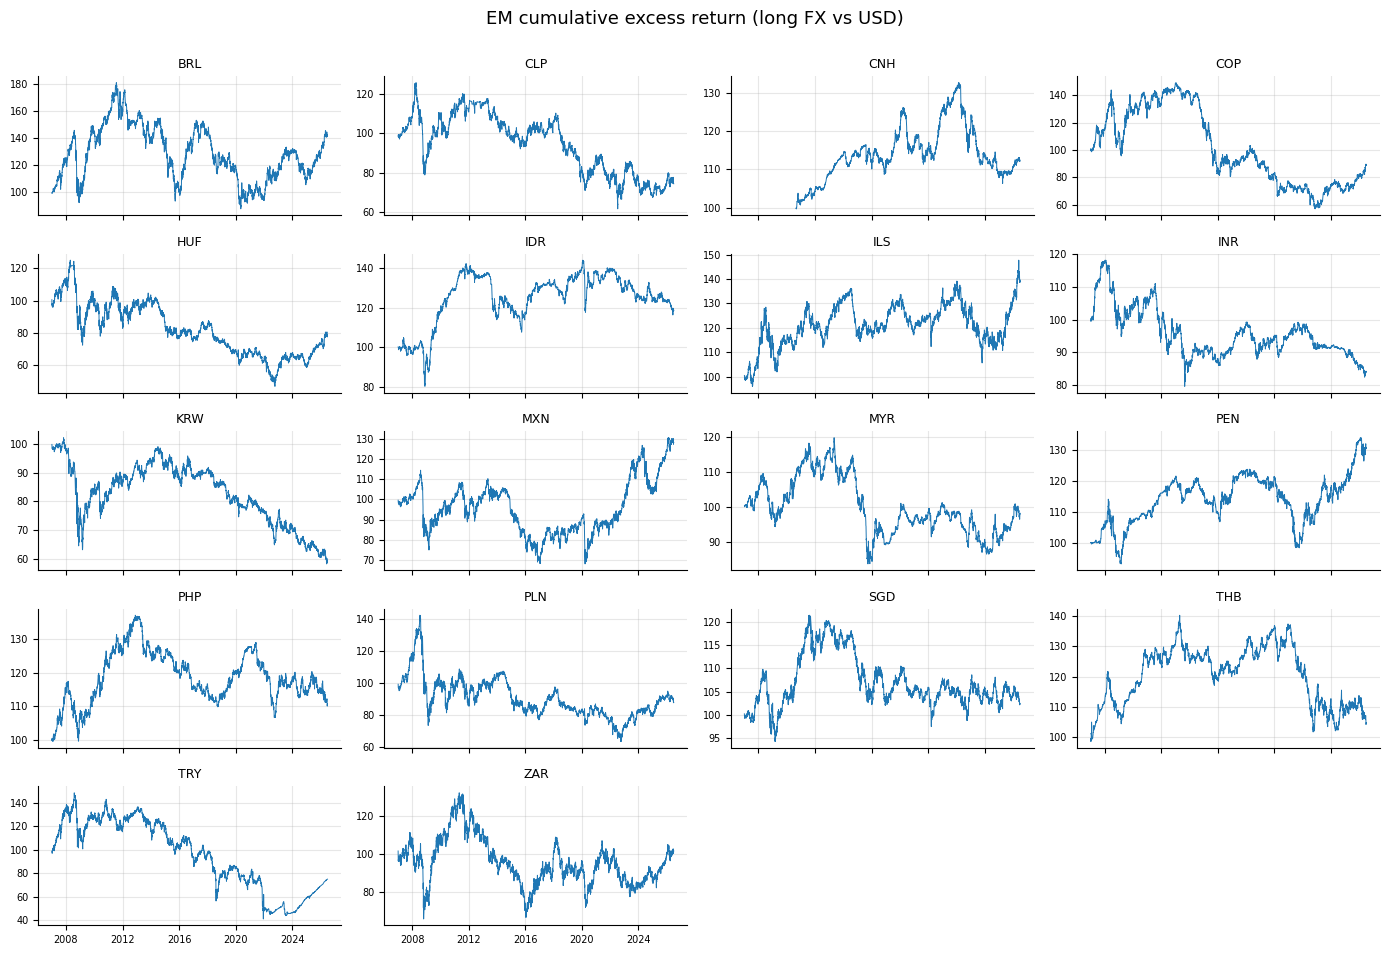

In [7]:
cum_x = 100 * (1 + xret.fillna(0)).cumprod().where(xret.notna().cummax())
ts_grid(cum_x[[c for c in fx.G10 if c in cum_x.columns]],
        title="G10 cumulative excess return (long FX vs USD)")
ts_grid(cum_x[[c for c in fx.EM if c in cum_x.columns]],
        title="EM cumulative excess return (long FX vs USD)")

### 3.4 FX implied volatility (ATM 1M, %) — risk pricing per pair

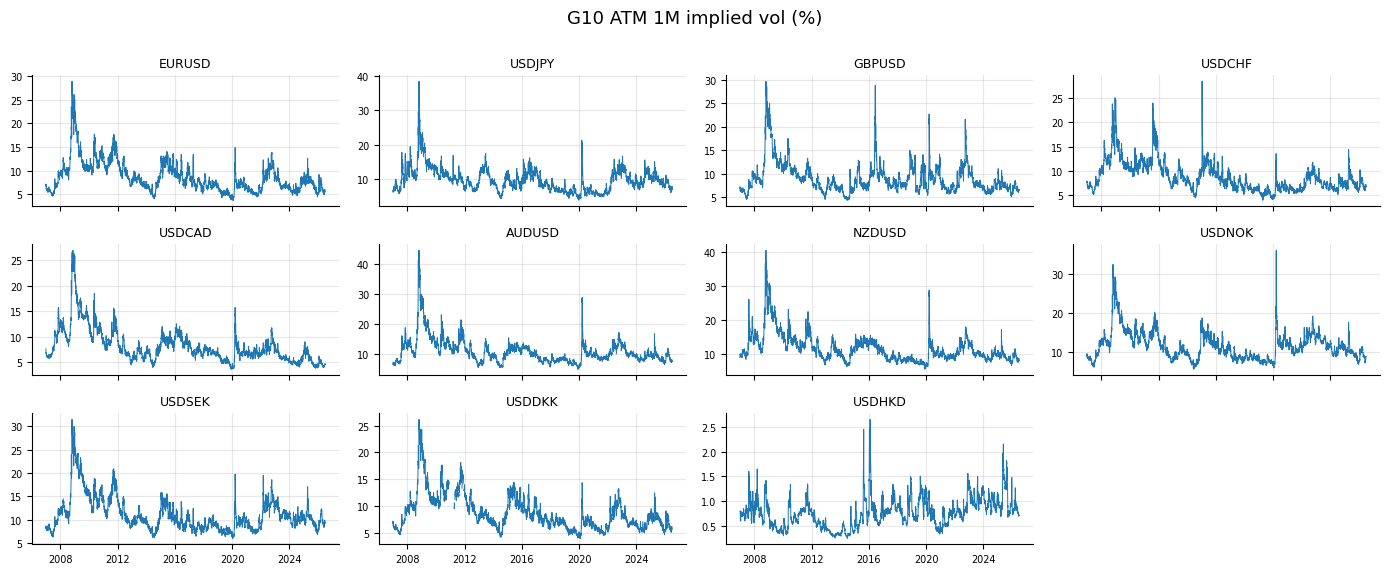

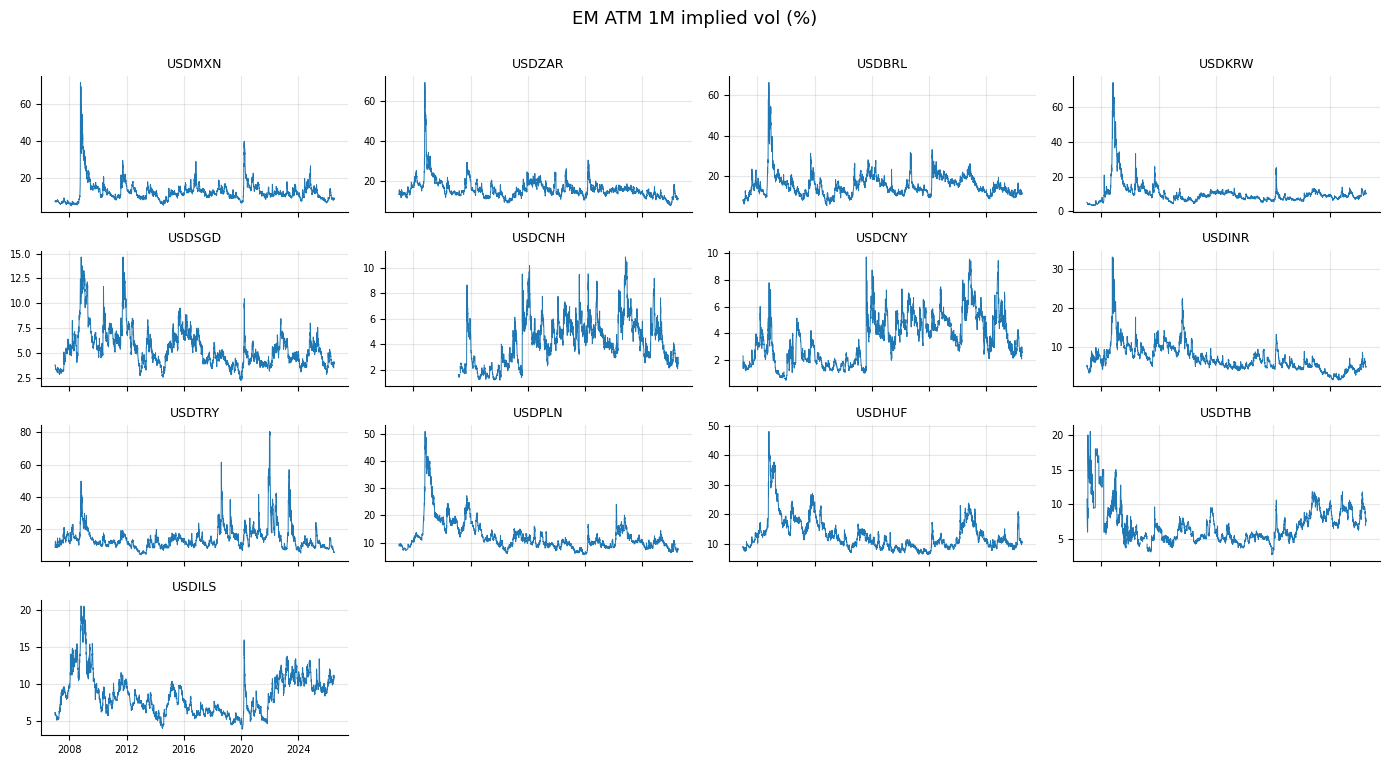

In [8]:
g10_pairs = ["EURUSD", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD",
             "NZDUSD", "USDNOK", "USDSEK", "USDDKK", "USDHKD"]
em_pairs = ["USD" + c for c in ["MXN", "ZAR", "BRL", "KRW", "SGD", "CNH", "CNY",
                                "INR", "TRY", "PLN", "HUF", "THB", "ILS"]]

atm_g10 = data["g10_fx_options"][[p + "V1M" for p in g10_pairs]].set_axis(g10_pairs, axis=1)
atm_em = data["em_fx_options"][[p + "V1M" for p in em_pairs]].set_axis(em_pairs, axis=1)
ts_grid(atm_g10, title="G10 ATM 1M implied vol (%)")
ts_grid(atm_em, title="EM ATM 1M implied vol (%)")

### 3.5 Interest rates (the other leg of CIP/UIP)

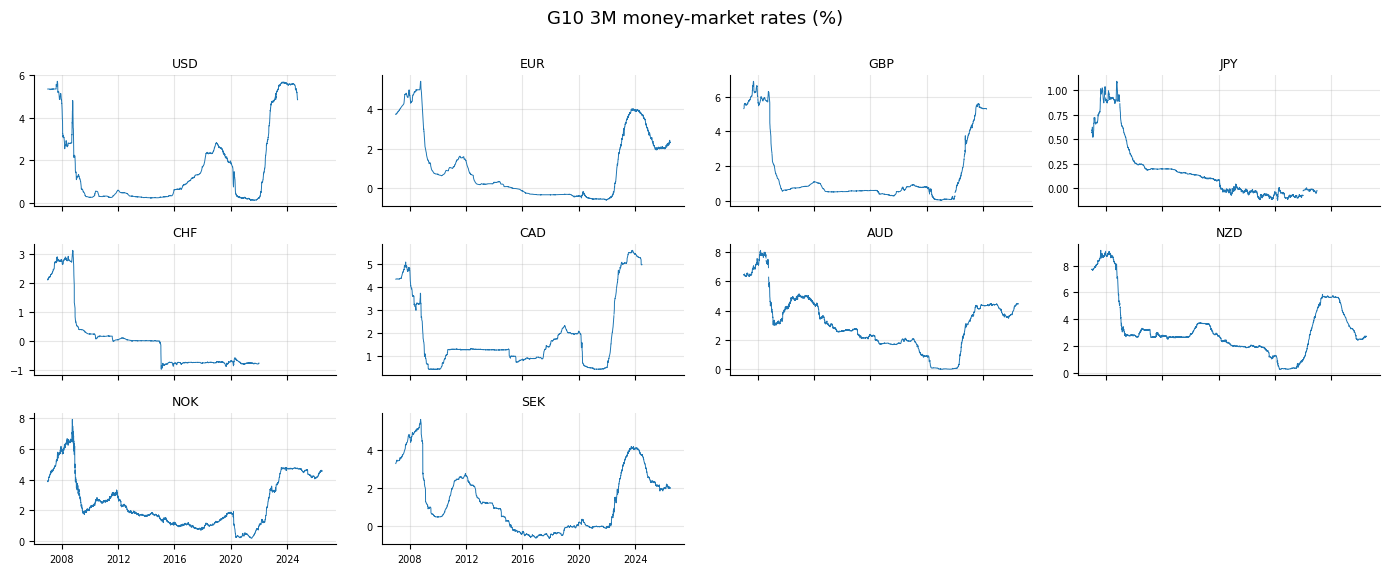

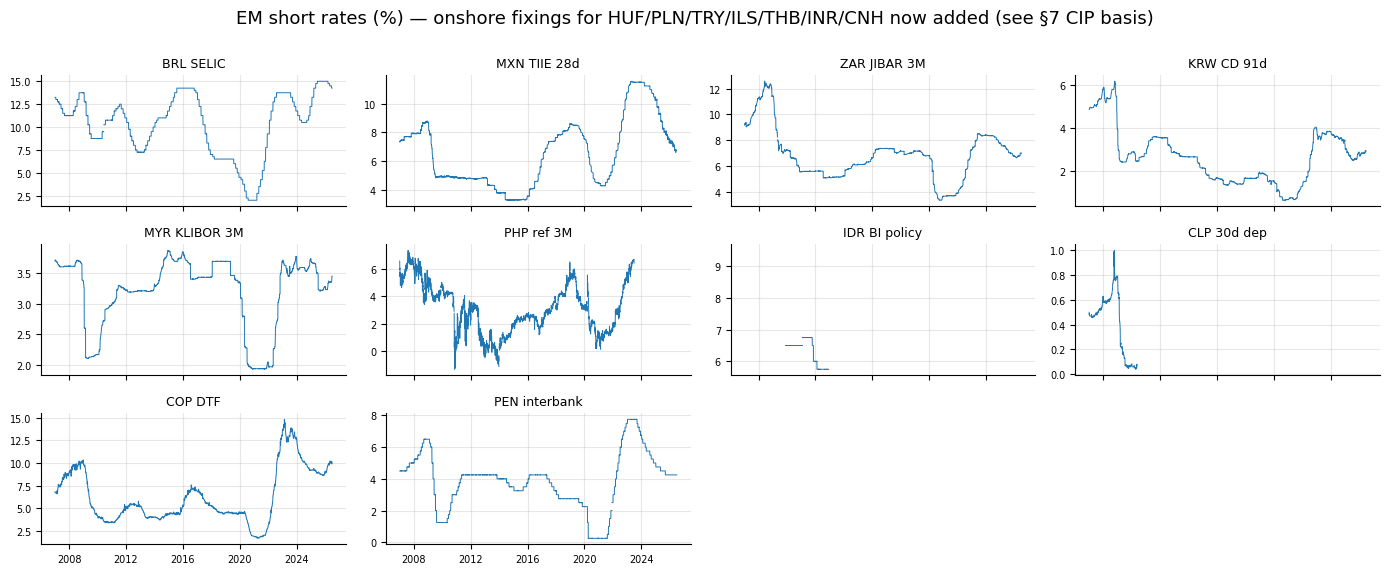

In [9]:
G10_3M = {"USD": "US0003M", "EUR": "EUR003M", "GBP": "BP0003M", "JPY": "JY0003M",
          "CHF": "SF0003M", "CAD": "CDOR03", "AUD": "ADBB3M", "NZD": "NDBB3M",
          "NOK": "NIBOR3M", "SEK": "STIB3M"}
EM_SHORT = {"BRL SELIC": "BZSTSETA", "MXN TIIE 28d": "MXIBTIIE", "ZAR JIBAR 3M": "JIBA3M",
            "KRW CD 91d": "KWCDC", "MYR KLIBOR 3M": "KLIB3M", "PHP ref 3M": "PREF3MO",
            "IDR BI policy": "IDBIRATE", "CLP 30d dep": "CLTN30DS", "COP DTF": "DTF RATE",
            "PEN interbank": "PRRRONUS"}

g10_ir, em_ir = data["g10_interest_rates"], data["em_interest_rates"]
r3m = pd.DataFrame({k: g10_ir[v] for k, v in G10_3M.items() if v in g10_ir.columns})
em_r = pd.DataFrame({k: em_ir[v] for k, v in EM_SHORT.items() if v in em_ir.columns})
ts_grid(r3m, title="G10 3M money-market rates (%)")
ts_grid(em_r, title="EM short rates (%) — onshore fixings for HUF/PLN/TRY/ILS/THB/INR/CNH now added (see §7 CIP basis)")

### 3.6 Global risk & macro factors

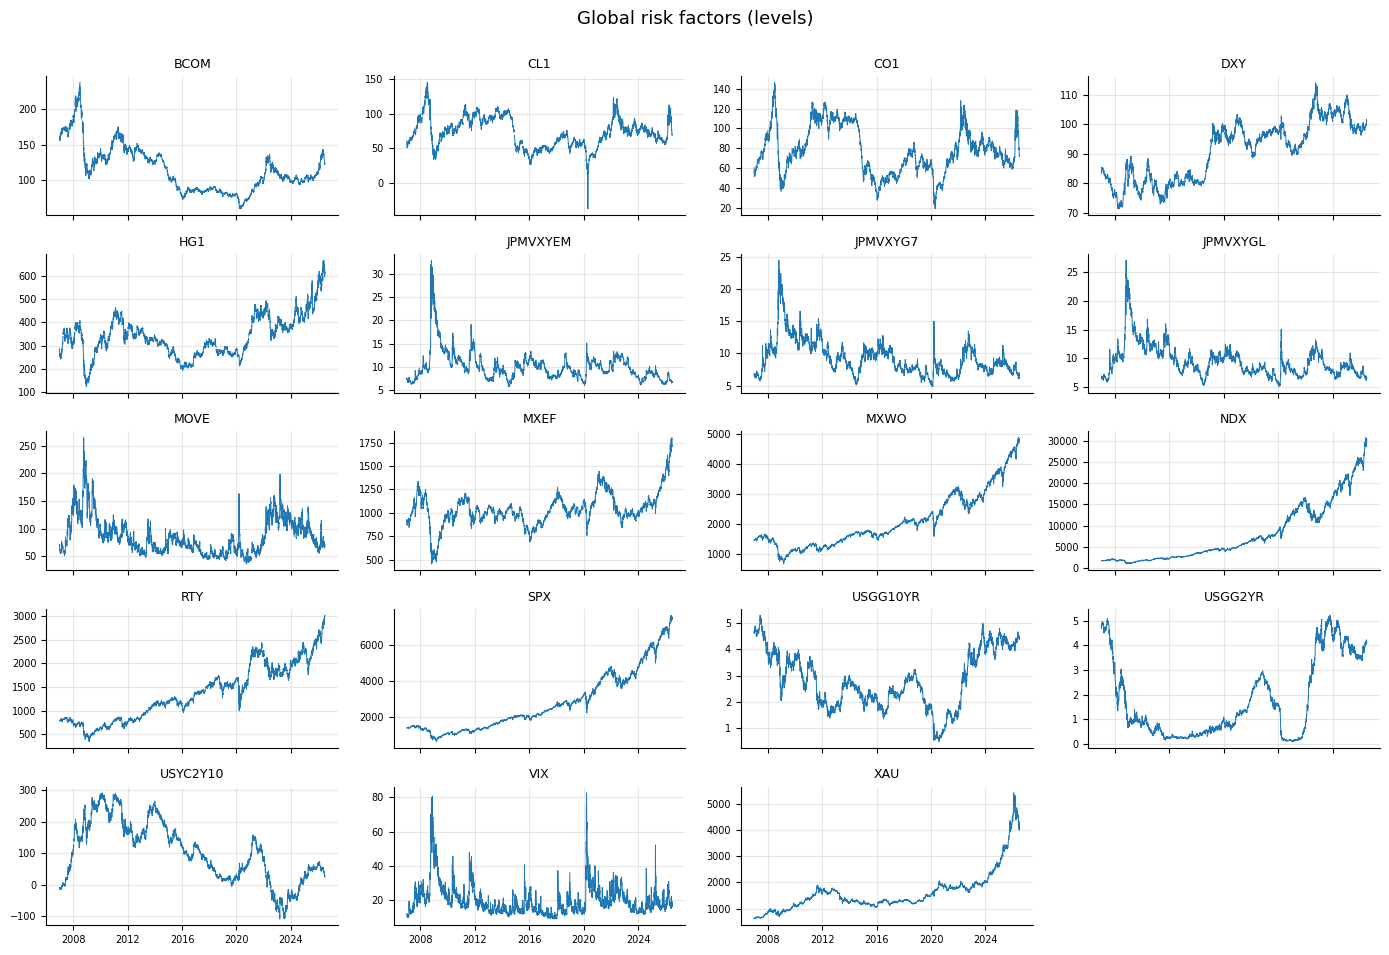

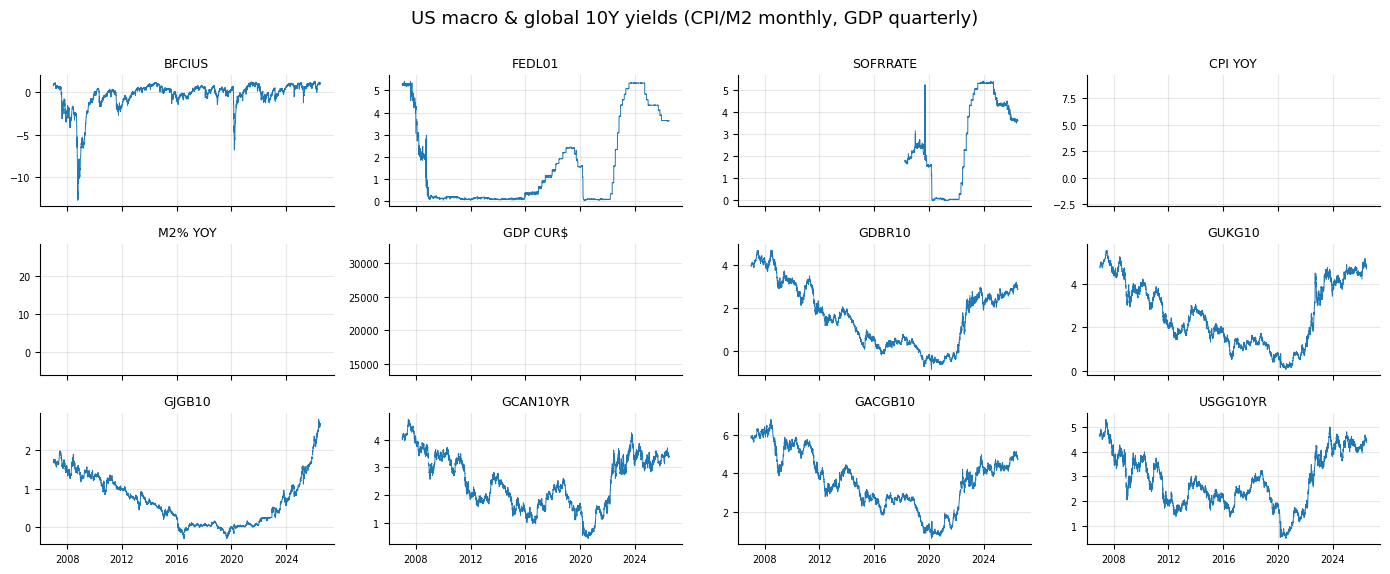

In [10]:
ts_grid(data["global_risk"], title="Global risk factors (levels)")

macro_sel = ["BFCIUS", "FEDL01", "SOFRRATE", "CPI YOY", "M2% YOY", "GDP CUR$",
             "GDBR10", "GUKG10", "GJGB10", "GCAN10YR", "GACGB10", "USGG10YR"]
macro = data["macro_market_proxies"]
ts_grid(macro[[c for c in macro_sel if c in macro.columns]],
        title="US macro & global 10Y yields (CPI/M2 monthly, GDP quarterly)")

## 4. Summary statistics

Computed on **daily returns**, annualised with 252 days.

| metric | definition |
|---|---|
| `ann_return`, `ann_vol` | mean·252, std·√252 |
| `daily_variance`, `skew`, `excess_kurtosis` | daily moments (kurtosis in excess of normal) |
| `sharpe` | ann_return / ann_vol — valid as-is for **carry excess returns** (already excess of USD cash); for spot returns it is descriptive only |
| `info_ratio` | active return vs the **equal-weighted all-currency basket (DOL)**, ÷ tracking error. A proper benchmark would be a carry index (DBHVG10U / FXCTEM8) — flagged in §6 |
| `max_drawdown` | worst peak-to-trough of the compounded wealth curve |
| `VaR_95/99`, `CVaR_95/99` | historical daily loss quantile / expected loss beyond it (positive = loss) |
| `hit_rate`, `autocorr_1d` | share of up days, 1-day return autocorrelation |

### 4.1 Carry excess returns (long FX vs USD via 1M forwards)

In [11]:
dol = fx.dollar_factor(xret)
stats_carry = fx.summary_stats(xret, benchmark=dol)
stats_carry.to_csv(OUT / "summary_stats_carry_excess.csv")
stats_carry.sort_values("sharpe", ascending=False).round(3)

,start,end,n_days,ann_return,ann_vol,daily_variance,skew,excess_kurtosis,sharpe,max_drawdown,VaR_95,VaR_99,CVaR_95,CVaR_99,hit_rate,best_day,worst_day,autocorr_1d,cagr,sortino,calmar,info_ratio
PEN,2007-01-03,2026-06-26,4591,0.016304,0.057672,0.000013,0.138709,7.188724,0.282698,-0.204576,0.005401,0.010247,0.008614,0.014413,0.527554,0.028656,-0.023071,0.037072,0.014749,0.40806,0.072095,0.226102
ILS,2007-01-03,2026-06-30,5027,0.020231,0.083623,0.000028,-0.071917,3.115749,0.241924,-0.240468,0.008394,0.014658,0.012108,0.019049,0.516212,0.03171,-0.029919,0.033019,0.016874,0.342795,0.070172,0.245309
BRL,2007-01-03,2026-06-30,4709,0.032266,0.163544,0.000106,-0.149893,4.454707,0.197293,-0.514991,0.016108,0.027425,0.023608,0.037491,0.511786,0.076333,-0.07081,-0.062632,0.019057,0.277828,0.037005,0.207492
CNH,2010-08-27,2026-06-30,4103,0.008034,0.041676,0.000007,0.026057,8.665128,0.192764,-0.198545,0.003909,0.007428,0.006172,0.009881,0.521813,0.019897,-0.02735,-0.020534,0.007191,0.275602,0.036219,0.346916
IDR,2007-01-03,2026-06-30,4589,0.011855,0.070317,0.00002,0.265217,21.876514,0.168592,-0.243591,0.005974,0.011271,0.010142,0.018885,0.511876,0.0647,-0.044441,0.074214,0.009429,0.243181,0.038707,0.17153
MXN,2007-01-03,2026-06-30,5044,0.020243,0.124511,0.000062,-0.728389,8.32762,0.162582,-0.406506,0.012293,0.021774,0.01889,0.031901,0.529144,0.066716,-0.079599,-0.019302,0.012539,0.219439,0.030847,0.23114
PHP,2007-01-04,2026-06-30,4574,0.006993,0.055591,0.000012,0.036499,2.233579,0.1258,-0.222395,0.005803,0.009006,0.007867,0.011149,0.515523,0.025347,-0.019332,-0.0341,0.005463,0.177772,0.024566,0.100748
ZAR,2007-01-02,2026-06-30,5068,0.014146,0.162833,0.000105,-0.934691,12.570946,0.086872,-0.498405,0.01649,0.026051,0.023584,0.0367,0.520916,0.066723,-0.154618,-0.016085,0.000796,0.117525,0.001597,0.129196
THB,2007-01-03,2026-06-30,4681,0.004285,0.058847,0.000014,0.082677,6.9359,0.072808,-0.274503,0.005704,0.010173,0.008511,0.013199,0.516129,0.032211,-0.038001,0.015749,0.002557,0.103935,0.009315,0.096236
AUD,2007-01-02,2026-06-30,5079,0.007356,0.123878,0.000061,-0.354591,10.57339,0.059382,-0.446676,0.011867,0.021375,0.018401,0.031549,0.516637,0.082829,-0.072825,-0.037766,-0.000332,0.081598,-0.000744,0.108761


### 4.2 Spot returns (USD-per-FX log returns — no carry leg)

Comparing 4.1 vs 4.2 per currency shows how much of the long-run P&L is carry vs spot: high-carry currencies (BRL, TRY, ZAR, MXN) typically bleed in spot and earn in carry — UIP failing in the cross-section is the whole strategy premise.

In [12]:
stats_spot = fx.summary_stats(spot_ret)
stats_spot.to_csv(OUT / "summary_stats_spot.csv")
stats_spot.sort_values("ann_return", ascending=False).round(3)

,start,end,n_days,ann_return,ann_vol,daily_variance,skew,excess_kurtosis,sharpe,max_drawdown,VaR_95,VaR_99,CVaR_95,CVaR_99,hit_rate,best_day,worst_day,autocorr_1d,cagr,sortino,calmar
CHF,2007-01-02,2026-06-30,5079,0.020233,0.103229,0.000042,4.875482,164.856338,0.195999,-0.333204,0.008925,0.014622,0.012871,0.020373,0.483363,0.193834,-0.090889,-0.021173,0.015115,0.307659,0.045362
ILS,2007-01-03,2026-06-30,5081,0.017504,0.084055,0.000028,-0.097944,3.137134,0.208241,-0.253983,0.008445,0.014674,0.01223,0.019285,0.512301,0.031747,-0.029979,0.03163,0.014068,0.293875,0.05539
CNY,2007-01-02,2026-06-30,4703,0.009082,0.031128,0.000004,-0.03958,8.693351,0.291767,-0.153969,0.00289,0.006,0.004781,0.00794,0.49394,0.01607,-0.018334,-0.005996,0.008635,0.416992,0.05608
SGD,2007-01-02,2026-06-30,5075,0.008745,0.051993,0.000011,0.029585,3.879236,0.168186,-0.186535,0.00508,0.008831,0.007323,0.011425,0.503842,0.023812,-0.026702,-0.012955,0.007421,0.240421,0.039781
HKD,2007-01-02,2026-06-30,5075,-0.000349,0.006159,0.0,0.959165,13.231717,-0.056639,-0.013262,0.000552,0.001081,0.000891,0.001482,0.458719,0.003973,-0.002663,0.010823,-0.000368,-0.085031,-0.027728
CNH,2010-08-24,2026-06-30,4121,-0.001796,0.041576,0.000007,0.038493,8.763253,-0.043202,-0.202778,0.003996,0.007354,0.006187,0.009901,0.501335,0.020003,-0.027472,-0.021504,-0.002657,-0.061256,-0.013101
THB,2007-01-02,2026-06-30,4725,-0.002034,0.058765,0.000014,0.100604,6.922484,-0.034616,-0.322672,0.005723,0.010077,0.008493,0.013119,0.492487,0.03174,-0.038132,0.017849,-0.003753,-0.049335,-0.011631
PEN,2007-01-03,2026-06-26,4673,-0.002158,0.057543,0.000013,0.152963,7.176113,-0.037507,-0.354189,0.005439,0.010288,0.008652,0.014355,0.487695,0.028488,-0.023214,0.039709,-0.003806,-0.053459,-0.010745
AUD,2007-01-02,2026-06-30,5079,-0.005696,0.123874,0.000061,-0.364121,10.579942,-0.045983,-0.492879,0.011891,0.021486,0.018486,0.031648,0.511715,0.082766,-0.072937,-0.037892,-0.013296,-0.06285,-0.026976
DKK,2007-01-02,2026-06-30,5077,-0.005996,0.087329,0.00003,0.102697,2.491067,-0.068663,-0.424797,0.008513,0.01515,0.01246,0.018085,0.499508,0.034991,-0.024358,0.009673,-0.00976,-0.097218,-0.022975


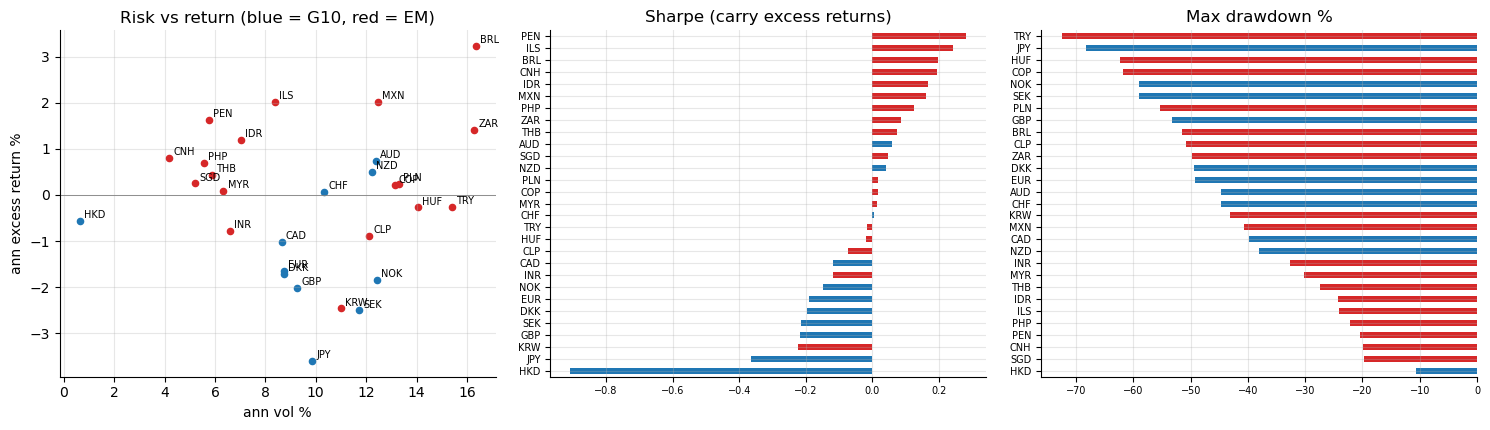

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for c in stats_carry.index:
    col = "tab:blue" if c in fx.G10 else "tab:red"
    axes[0].scatter(stats_carry.loc[c, "ann_vol"] * 100, stats_carry.loc[c, "ann_return"] * 100,
                    color=col, s=20)
    axes[0].annotate(c, (stats_carry.loc[c, "ann_vol"] * 100, stats_carry.loc[c, "ann_return"] * 100),
                     fontsize=7, xytext=(3, 2), textcoords="offset points")
axes[0].axhline(0, color="grey", lw=0.6)
axes[0].set(xlabel="ann vol %", ylabel="ann excess return %",
            title="Risk vs return (blue = G10, red = EM)")

sh = stats_carry["sharpe"].astype(float).sort_values()
sh.plot.barh(ax=axes[1], color=["tab:blue" if c in fx.G10 else "tab:red" for c in sh.index])
axes[1].set(title="Sharpe (carry excess returns)")
axes[1].tick_params(labelsize=7)

dd = stats_carry["max_drawdown"].astype(float).sort_values(ascending=False)
(100 * dd).plot.barh(ax=axes[2], color=["tab:blue" if c in fx.G10 else "tab:red" for c in dd.index])
axes[2].set(title="Max drawdown %")
axes[2].tick_params(labelsize=7)
fig.tight_layout()
plt.show()

## 5. What drives returns — factor regressions

Two complementary lenses, per the papers in `papers/`:

**(a) Lustig–Roussanov–Verdelhan currency factors**, built from our own panel:
- `DOL` — equal-weighted long-all-currencies-vs-USD (the "dollar" factor);
- `HML_FX` — long the top third / short the bottom third by 1M implied carry, monthly rebalance, no lookahead. This *is* a naive carry strategy, so each currency's `HML_FX` beta says whether it behaves like an investment (+) or funding (−) currency.

**(b) Market/macro factors** (daily, from `global_risk`): equity (`SPX`, `MXEF`), commodities (`BCOM`), the dollar (`DXY`), risk aversion (`ΔVIX`), FX implied vol (`ΔJPMVXYGL`), US front-end (`ΔUST2Y`) and curve slope (`Δ2s10s`). Monthly/quarterly series (CPI, M2, GDP) are excluded from daily regressions.

All regressions use **Newey–West (HAC, 5 lags)** t-statistics. Alpha is annualised.

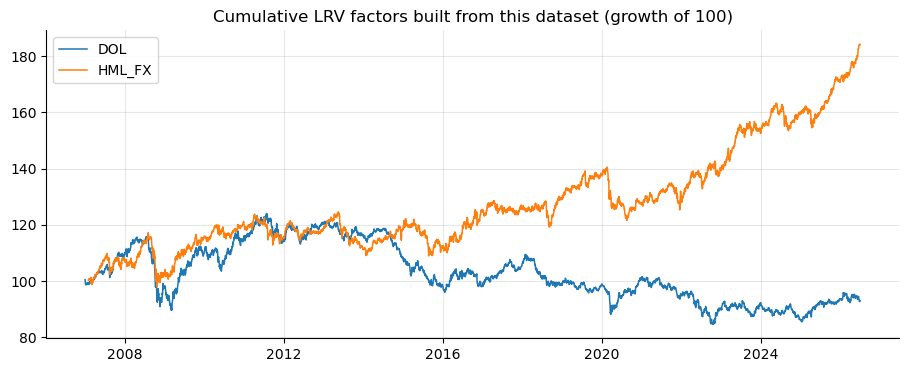

HML_FX: ann ret 3.25%, Sharpe 0.50


In [14]:
hml = fx.carry_hml_factor(xret, carry_1m)
lrv_factors = pd.concat([dol, hml], axis=1)

risk_d = data["global_risk"]
macro_factors = pd.DataFrame({
    "SPX_ret": np.log(risk_d["SPX"]).diff(),
    "MXEF_ret": np.log(risk_d["MXEF"]).diff(),
    "BCOM_ret": np.log(risk_d["BCOM"]).diff(),
    "DXY_ret": np.log(risk_d["DXY"]).diff(),
    "dVIX": risk_d["VIX"].diff(),
    "dFXvol": risk_d["JPMVXYGL"].diff(),
    "dUST2Y": risk_d["USGG2YR"].diff(),
    "d2s10s": risk_d["USYC2Y10"].diff(),
})

fig, ax = plt.subplots(figsize=(11, 4))
for c, s in lrv_factors.items():
    ax.plot(100 * (1 + s.dropna()).cumprod(), lw=1.1, label=c)
ax.legend()
ax.set_title("Cumulative LRV factors built from this dataset (growth of 100)")
plt.show()
print("HML_FX: ann ret {:.2%}, Sharpe {:.2f}".format(
    hml.mean() * 252, hml.mean() * 252 / (hml.std() * np.sqrt(252))))

### 5.1 LRV two-factor regressions: $r^{xs}_i = \alpha + \beta_{DOL}\,DOL + \beta_{HML}\,HML_{FX} + \varepsilon$

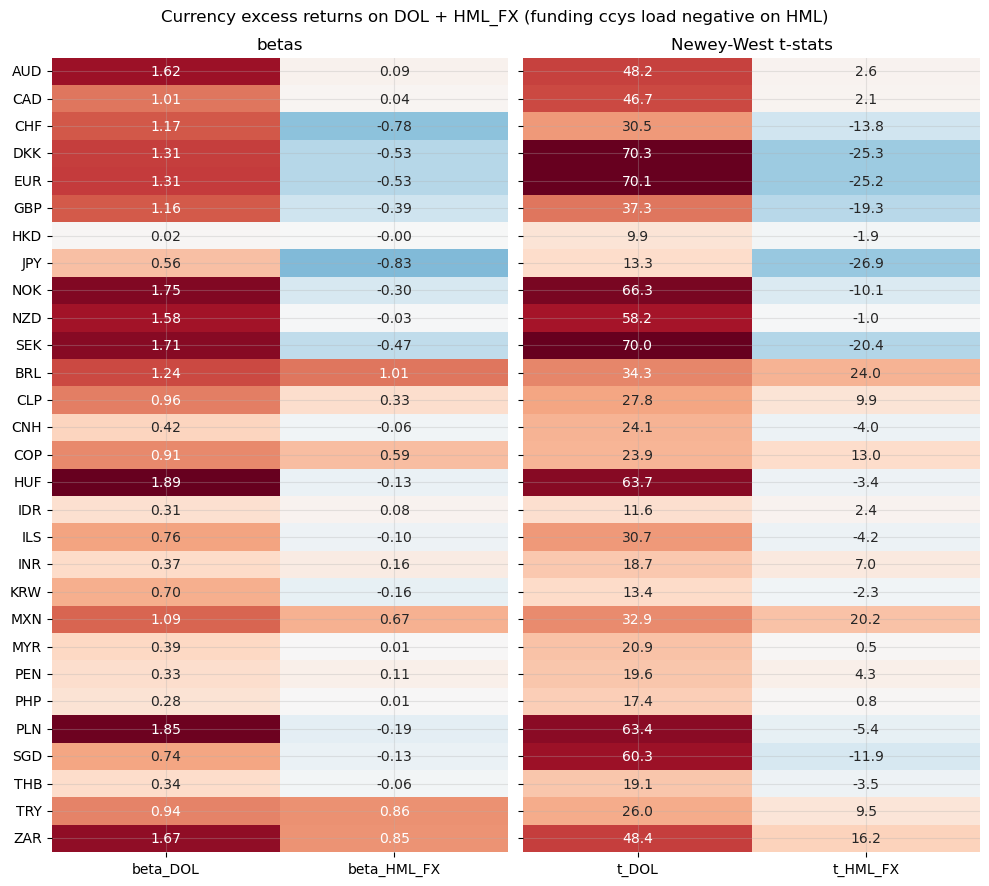

,n,r2,alpha_ann,alpha_t,beta_DOL,t_DOL,beta_HML_FX,t_HML_FX
AUD,5057.0,0.654,0.007,0.501,1.617,48.235,0.090,2.556
CAD,5057.0,0.517,-0.010,-0.758,1.009,46.692,0.040,2.071
CHF,5057.0,0.499,0.029,1.773,1.170,30.478,-0.780,-13.831
DKK,5055.0,0.756,0.002,0.164,1.312,70.297,-0.528,-25.349
EUR,5057.0,0.756,0.003,0.292,1.313,70.107,-0.526,-25.225
GBP,5057.0,0.522,-0.006,-0.425,1.162,37.346,-0.394,-19.299
HKD,5052.0,0.026,-0.005,-3.849,0.017,9.934,-0.004,-1.938
JPY,5057.0,0.302,-0.007,-0.414,0.558,13.295,-0.834,-26.875
NOK,5051.0,0.665,-0.007,-0.467,1.746,66.302,-0.304,-10.144
NZD,5057.0,0.606,0.009,0.533,1.575,58.188,-0.026,-0.954


In [15]:
tab_lrv = fx.regression_table(xret, lrv_factors)
tab_lrv.to_csv(OUT / "regression_lrv.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 9), sharey=True)
sns.heatmap(tab_lrv[["beta_DOL", "beta_HML_FX"]].astype(float), cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", cbar=False, ax=axes[0])
axes[0].set_title("betas")
sns.heatmap(tab_lrv[["t_DOL", "t_HML_FX"]].astype(float), cmap="RdBu_r", center=0,
            annot=True, fmt=".1f", cbar=False, ax=axes[1])
axes[1].set_title("Newey-West t-stats")
fig.suptitle("Currency excess returns on DOL + HML_FX (funding ccys load negative on HML)")
fig.tight_layout()
plt.show()
tab_lrv.round(3)

### 5.2 Macro factor regressions — what moved each currency

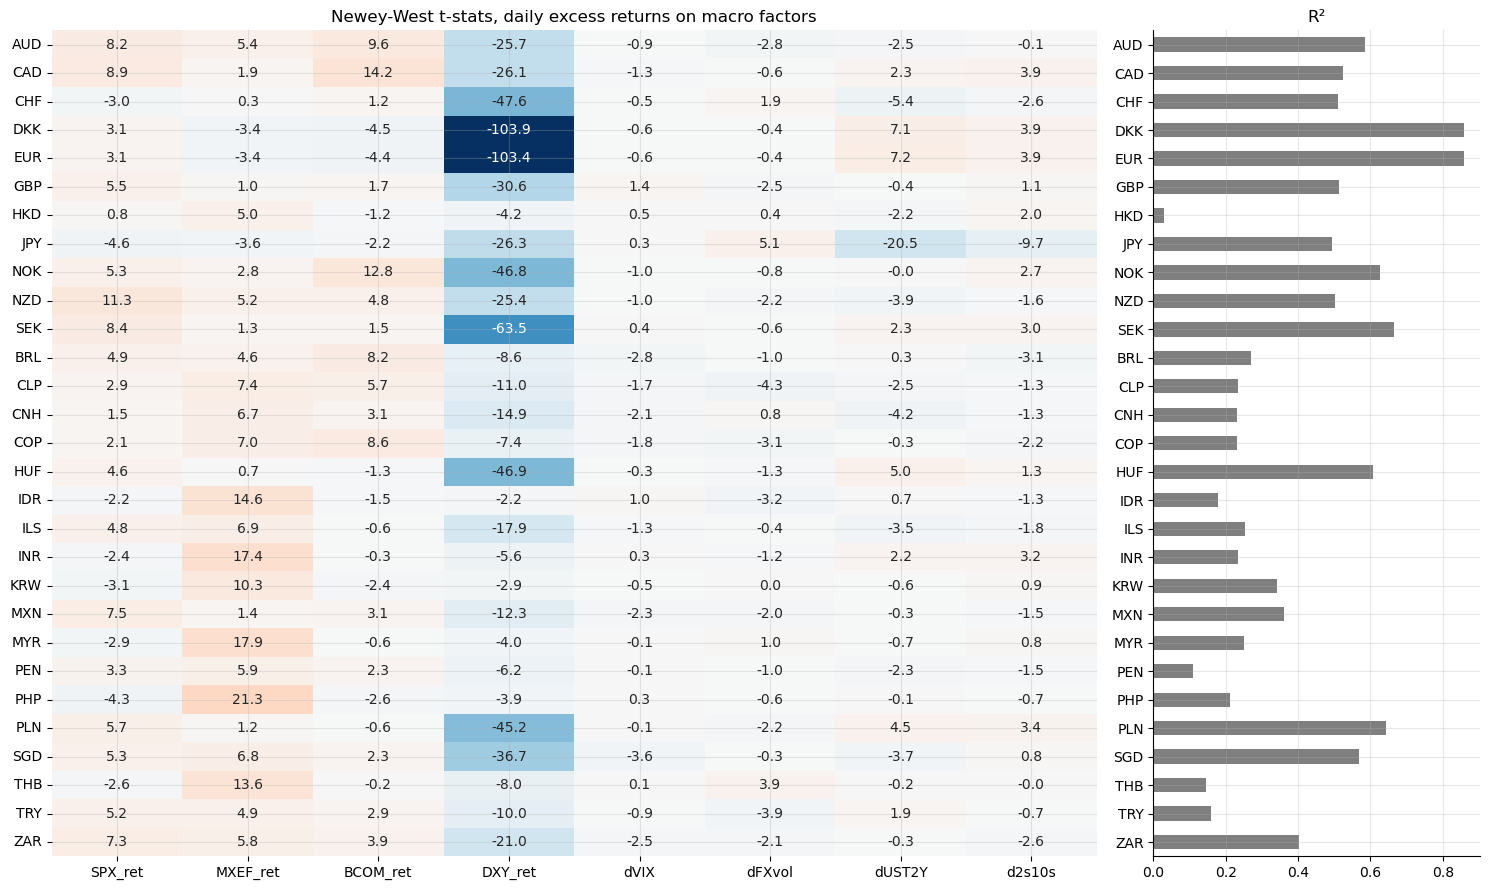

,n,r2,alpha_ann,alpha_t,beta_SPX_ret,t_SPX_ret,beta_MXEF_ret,t_MXEF_ret,beta_BCOM_ret,t_BCOM_ret,beta_DXY_ret,t_DXY_ret,beta_dVIX,t_dVIX,beta_dFXvol,t_dFXvol,beta_dUST2Y,t_dUST2Y,beta_d2s10s,t_d2s10s
AUD,4697.0,0.584,-0.011,-0.679,0.205,8.200,0.072,5.400,0.101,9.608,-0.705,-25.653,-0.000,-0.937,-0.003,-2.795,-0.005,-2.461,-0.0,-0.121
CAD,4697.0,0.525,-0.013,-1.028,0.143,8.942,0.017,1.938,0.107,14.176,-0.471,-26.106,-0.000,-1.284,-0.000,-0.619,0.004,2.309,0.0,3.936
CHF,4697.0,0.510,0.020,1.310,-0.040,-2.963,0.006,0.330,0.009,1.249,-0.959,-47.613,-0.000,-0.479,0.003,1.915,-0.013,-5.387,-0.0,-2.593
DKK,4697.0,0.859,-0.010,-1.763,0.025,3.120,-0.019,-3.370,-0.020,-4.472,-1.120,-103.941,-0.000,-0.586,-0.000,-0.372,0.006,7.051,0.0,3.942
EUR,4697.0,0.860,-0.009,-1.524,0.025,3.111,-0.019,-3.405,-0.020,-4.398,-1.121,-103.352,-0.000,-0.626,-0.000,-0.426,0.006,7.201,0.0,3.931
GBP,4697.0,0.512,-0.012,-0.841,0.076,5.533,0.008,1.013,0.014,1.664,-0.795,-30.612,0.000,1.401,-0.002,-2.475,-0.001,-0.363,0.0,1.109
HKD,4697.0,0.030,-0.005,-3.585,0.001,0.792,0.004,4.998,-0.001,-1.218,-0.006,-4.179,0.000,0.476,0.000,0.368,-0.000,-2.155,0.0,2.020
JPY,4697.0,0.493,-0.020,-1.298,-0.093,-4.588,-0.033,-3.574,-0.021,-2.249,-0.615,-26.308,0.000,0.322,0.003,5.078,-0.042,-20.520,-0.0,-9.684
NOK,4695.0,0.627,-0.018,-1.112,0.132,5.332,0.030,2.806,0.135,12.822,-1.002,-46.776,-0.000,-1.042,-0.000,-0.779,-0.000,-0.017,0.0,2.677
NZD,4697.0,0.503,-0.009,-0.500,0.197,11.262,0.056,5.233,0.056,4.848,-0.750,-25.371,-0.000,-1.034,-0.002,-2.182,-0.008,-3.905,-0.0,-1.574


In [16]:
tab_macro = fx.regression_table(xret, macro_factors)
tab_macro.to_csv(OUT / "regression_macro.csv")

tcols = [c for c in tab_macro.columns if c.startswith("t_")]
fig, axes = plt.subplots(1, 2, figsize=(15, 9), width_ratios=[3.2, 1])
sns.heatmap(tab_macro[tcols].astype(float).rename(columns=lambda c: c[2:]),
            cmap="RdBu_r", center=0, annot=True, fmt=".1f", cbar=False, ax=axes[0])
axes[0].set_title("Newey-West t-stats, daily excess returns on macro factors")
tab_macro["r2"].astype(float).reindex(tab_macro.index[::-1]).plot.barh(ax=axes[1], color="tab:grey")
axes[1].set_title("R²")
fig.tight_layout()
plt.show()
tab_macro.round(3)

### 5.3 Correlation snapshot (daily excess returns vs factors)

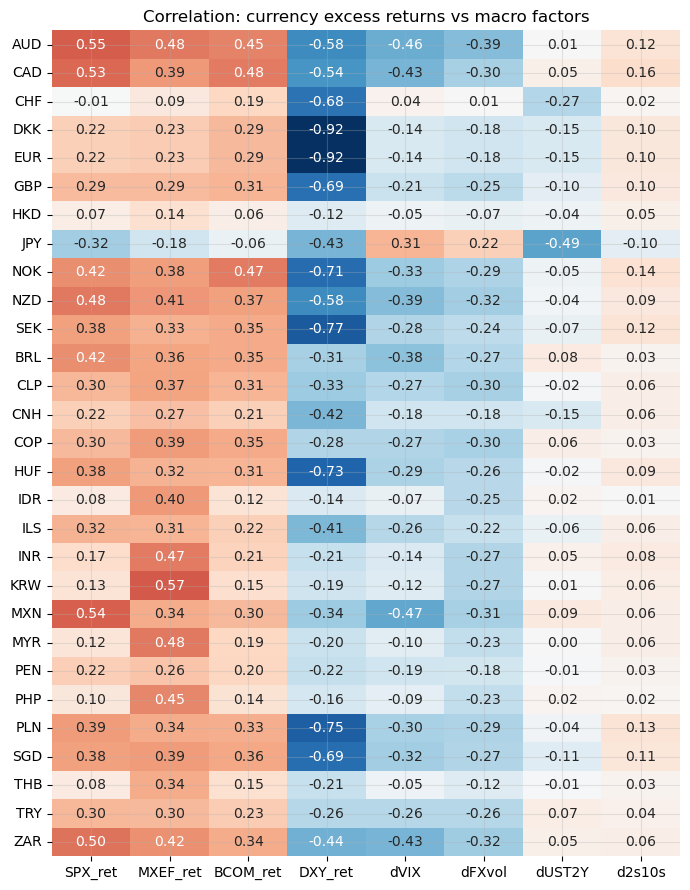

In [17]:
corr = pd.concat([xret, macro_factors], axis=1).corr().loc[xret.columns, macro_factors.columns]
plt.figure(figsize=(7, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", cbar=False)
plt.title("Correlation: currency excess returns vs macro factors")
plt.tight_layout()
plt.show()

## 6. Data gaps & recommended Bloomberg additions

In [18]:
print("Original 8-group download coverage:")
print(pd.read_csv("../data/raw/download_coverage_summary.csv").to_string(index=False))

print("\nPhase-2 supplemental groups (hand-pulled, from FX_extra_data.xlsx):")
extra = ["usd_riskfree", "fx_carry_benchmarks", "g10_rates_gaps", "em_onshore_rates", "em_risk"]
extra_cov = pd.DataFrame({g: {"tickers": data[g].shape[1],
                              "start": data[g].index.min().date(),
                              "end": data[g].index.max().date(),
                              "non_nan_%": round(100 * data[g].notna().mean().mean(), 1),
                              "series": ", ".join(data[g].columns)}
                          for g in extra}).T
print(extra_cov.to_string())

print("\nStill-missing original tickers (all have working substitutes — see §2 / §9 notes):")
pd.read_csv("../data/raw/missing_tickers_by_group.csv")

Original 8-group download coverage:
               group  requested  fetched  missing  extra  csv_exists
       em_fx_options        325      325        0      0        True
  em_fx_spot_forward        103       95        8      0        True
   em_interest_rates         35       34        1      0        True
      g10_fx_options        275      275        0      0        True
 g10_fx_spot_forward         66       66        0      0        True
  g10_interest_rates         83       81        2      0        True
         global_risk         19       19        0      0        True
macro_market_proxies         24       24        0      0        True

Phase-2 supplemental groups (hand-pulled, from FX_extra_data.xlsx):
                    tickers       start         end non_nan_%                                                                                                                                     series
usd_riskfree              1  2007-01-01  2026-07-06     100.0            

,group,ticker,note
0,em_fx_spot_forward,CNY1M Curncy,requested but not found in saved long CSV
1,em_fx_spot_forward,CNY3M Curncy,requested but not found in saved long CSV
2,em_fx_spot_forward,CNY6M Curncy,requested but not found in saved long CSV
3,em_fx_spot_forward,CNY12M Curncy,requested but not found in saved long CSV
4,em_fx_spot_forward,INR1M Curncy,requested but not found in saved long CSV
5,em_fx_spot_forward,INR3M Curncy,requested but not found in saved long CSV
6,em_fx_spot_forward,INR6M Curncy,requested but not found in saved long CSV
7,em_fx_spot_forward,INR12M Curncy,requested but not found in saved long CSV
8,g10_interest_rates,NIBOR12M Index,requested but not found in saved long CSV
9,g10_interest_rates,STIB12M Index,requested but not found in saved long CSV


**Status: resolved.** The Phase-2 additions were pulled from Bloomberg **by hand** (the machine here has no local `blpapi`) and saved as `data/raw/FX_extra_data.xlsx`, converted to parquet by [`src/convert_extra_xlsx.py`](../src/convert_extra_xlsx.py), and loaded above like any other group.

| group | what | tickers obtained |
|---|---|---|
| `usd_riskfree` | clean USD risk-free anchor | `USGG3M` |
| `fx_carry_benchmarks` | benchmark for information ratios & HML sanity check | `DBHVG10U`, `FXCTEM8`, `DBHVBUSI` |
| `g10_rates_gaps` | DKK/HKD money-market fixings (only G10 gaps) | `CIBO01M/03M`, `HIHD01M/03M` |
| `em_onshore_rates` | onshore fixings → CIP-basis checks (§7) | HUF `BUBOR`, PLN `WIBR`, TRY `TRLIB`, ILS `TELBOR`, THB `THFX`, INR `IRSWOA/IRSWOC`+`NSERO`+`GIND3M`, CNH `SHIF` |
| `em_risk` | EM sovereign credit factor | `JPEIGLSP` (EMBI Global spread) |

**Substitutions during the manual pull** (the originally-guessed tickers were invalid/unentitled on the terminal): INR MIBOR/MIFOR → MIBOR-OIS (`IRSWOA/IRSWOC`) + T-bill (`GIND3M`) + o/n `NSERO`; CNH HIBOR → onshore SHIBOR (`SHIF1M/3M`, a China-onshore proxy, **not** the offshore CNH funding rate); SGD SORA dropped — SGD OIS (`SDSOAA/C/F`) is already in `g10_interest_rates`. Still deferred (optional, non-blocking): CFTC/IMM positioning overlay. The `CNY`/`INR` outright-forward and `NIBOR12M`/`STIB12M`/`CLSWA` gaps keep their existing substitutes (CNH; 3M fixings; `CHSWP1`).

## 7. CIP basis check

Now that onshore money-market fixings are in the panel (§1), we can test **covered interest parity** directly. The forward-implied carry (`fx.carry_panel`, needs no rate data) should equal the **onshore interest-rate differential vs USD LIBOR** (`fx.interest_diff_vs_usd`). Their difference is the **cross-currency basis**:

$$\text{basis} = \underbrace{\tfrac{12}{m}\ln(S/F)}_{\text{forward-implied carry}} - \underbrace{\big(r^{\text{onshore}}_{fx} - r^{\text{LIBOR}}_{usd}\big)}_{\text{rate differential}}$$

≈ 0 where CIP holds (deliverable currencies); materially non-zero and persistent where capital controls / NDF convertibility premia bite. Computed for currencies with both a forward and an onshore fixing: HUF, PLN, TRY, ILS, THB, INR, CNH (+ pegged DKK, HKD). **Caveat:** INR uses MIBOR-OIS and CNH uses onshore SHIBOR (not the offshore CNH funding rate), so their basis mixes true CIP deviations with a proxy mismatch.

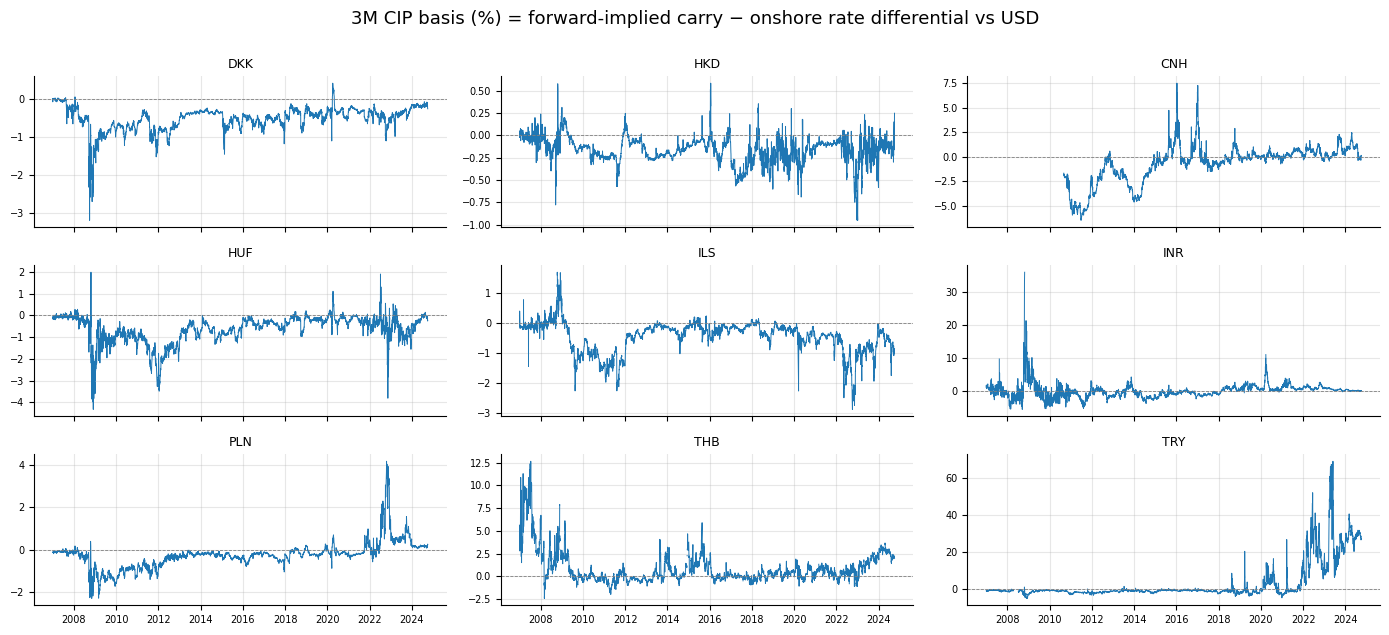

fwd_carry_%  onshore_diff_%  basis_%  basis_sd_%       n
tenor ccy                                                          
1M    DKK        -1.08           -0.44    -0.43        0.32  4484.0
      HKD        -0.31           -0.13    -0.13        0.16  4484.0
      CNH         1.26            2.21    -0.25        2.09  3547.0
      HUF         2.23            2.68    -0.47        0.62  4430.0
      ILS        -0.43           -0.09    -0.34        0.50  4440.0
      INR         4.37            4.30    -0.01        2.73  4183.0
      PLN         1.19            1.47    -0.22        0.54  4478.0
      THB         0.64            0.35     0.42        2.37  4305.0
      TRY        11.61           10.64    -0.60       12.38  4483.0
3M    DKK        -1.06           -0.45    -0.46        0.31  4484.0
      HKD        -0.30           -0.10    -0.15        0.15  4483.0
      CNH         1.31            2.09    -0.18        1.90  3543.0
      HUF         2.16            2.51    -0.48        0.64  4484.0
      ILS        -0.57           -0.20    -0.33        0.53  4468.0
      INR         4.34            4.13     0.06        2.21  4180.0
      PLN         1.11            1.41    -0.23        0.63  4477.0
      THB         0.53            0.24     0.31        1.83  4329.0
      TRY        11.22           10.79    -0.96       10.46  4428.0

In [19]:
# §7 CIP basis: forward-implied carry vs onshore rate differential vs USD LIBOR.
rates = fx.load_rates_panel()
cip_rows = {}
for tenor in ["1M", "3M"]:
    basis = fx.cip_basis(g10_fx, em_fx, tenor=tenor, rates=rates)
    carry = fx.carry_panel(g10_fx, em_fx, tenor)
    diff = fx.interest_diff_vs_usd(tenor=tenor, rates=rates)
    for c in basis.columns:
        cip_rows[(tenor, c)] = {
            "fwd_carry_%": carry[c].median() * 100,
            "onshore_diff_%": diff[c].median() * 100,
            "basis_%": basis[c].median() * 100,
            "basis_sd_%": basis[c].std() * 100,
            "n": int(basis[c].notna().sum()),
        }
cip_tab = pd.DataFrame(cip_rows).T
cip_tab.index.names = ["tenor", "ccy"]
cip_tab.to_csv(OUT / "cip_basis_summary.csv")

basis_3m = 100 * fx.cip_basis(g10_fx, em_fx, "3M", rates=rates)
ts_grid(basis_3m, ncols=3, height=2.1, zero_line=True,
        title="3M CIP basis (%) = forward-implied carry − onshore rate differential vs USD")
cip_tab.round(2)

## 8. UIP / Fama regressions

The empirical licence for carry. Regress each currency's realised **next-month** spot change (USD per FX) on its **forward premium** $f_t - s_t$ (monthly, 1M tenor):

$$\Delta s_{t+1} = a + b\,(f_t - s_t) + \varepsilon_{t+1}$$

Uncovered interest parity predicts $b = 1$ (a forward discount is fully paid back by depreciation). The **forward-premium puzzle** is $b < 1$ — often $b < 0$: high-yield currencies (trading at a forward discount) tend to *appreciate*, so the carry is not arbitraged away. Newey–West (HAC, 3 monthly lags) t-stats; `POOLED` stacks all currencies.

UIP null: b = 1. Forward-premium puzzle: b < 1 (often < 0 → high-carry FX tends to appreciate).
Currencies with b < 1: 59%  |  pooled b = 0.73 (t = 4.5)


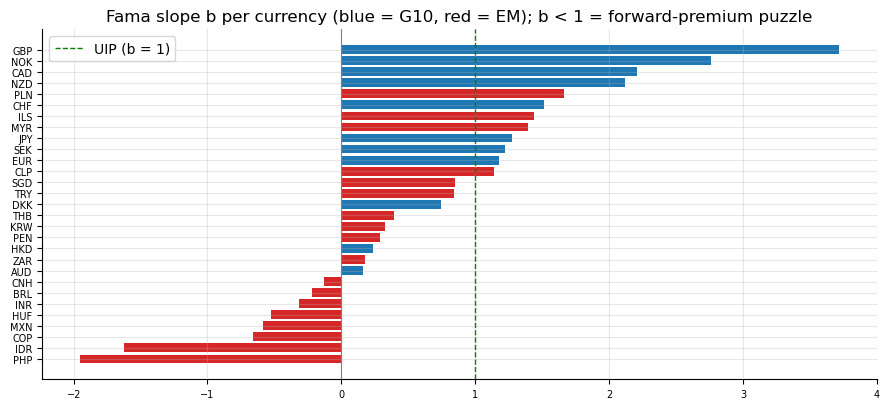

,beta,t_beta,r2,n
PHP,-1.951,-1.825,0.014,233.0
IDR,-1.627,-2.454,0.022,233.0
COP,-0.663,-0.659,0.002,233.0
MXN,-0.585,-0.334,0.001,233.0
HUF,-0.529,-0.540,0.001,232.0
INR,-0.319,-0.578,0.001,233.0
BRL,-0.216,-0.183,0.000,233.0
CNH,-0.131,-0.291,0.000,190.0
AUD,0.158,0.109,0.000,233.0
ZAR,0.180,0.077,0.000,233.0


In [20]:
# §8 UIP / Fama: Δs_{t+1} = a + b·(f_t − s_t), monthly, per currency.
# Forward premium f−s (USD-per-FX, per-period) = −carry/12 at the 1M tenor.
s_me = np.log(spots).resample("ME").last()
dspot_next = s_me.diff().shift(-1)                    # realised next-month appreciation, aligned at t
fwd_prem = (-carry_1m / 12).resample("ME").last()     # f_t − s_t (USD per FX)

fama = {}
for ccy in fwd_prem.columns:
    if ccy not in dspot_next.columns:
        continue
    X = fwd_prem[[ccy]].rename(columns={ccy: "fwd_prem"})
    res = fx.nw_regression(dspot_next[ccy], X, lags=3, min_obs=60)
    if res:
        fama[ccy] = {"beta": res["beta_fwd_prem"], "t_beta": res["t_fwd_prem"],
                     "r2": res["r2"], "n": res["n"]}
fama_tab = pd.DataFrame(fama).T

# Pooled panel across all currencies.
long = pd.concat([pd.DataFrame({"dspot": dspot_next[c], "fwd_prem": fwd_prem[c]})
                  for c in fama_tab.index], ignore_index=True).dropna()
pooled = fx.nw_regression(long["dspot"], long[["fwd_prem"]], lags=3, min_obs=100)
fama_tab.loc["POOLED"] = {"beta": pooled["beta_fwd_prem"], "t_beta": pooled["t_fwd_prem"],
                          "r2": pooled["r2"], "n": pooled["n"]}
fama_tab = fama_tab.round(3)
fama_tab.to_csv(OUT / "uip_fama.csv")

share_puzzle = (fama_tab["beta"].drop("POOLED") < 1).mean()
print("UIP null: b = 1. Forward-premium puzzle: b < 1 (often < 0 → high-carry FX tends to appreciate).")
print(f"Currencies with b < 1: {share_puzzle:.0%}  |  pooled b = {fama_tab.loc['POOLED', 'beta']:.2f} "
      f"(t = {fama_tab.loc['POOLED', 't_beta']:.1f})")

fig, ax = plt.subplots(figsize=(9, 4.2))
bt = fama_tab["beta"].drop("POOLED").sort_values()
ax.barh(bt.index, bt.values, color=["tab:blue" if c in fx.G10 else "tab:red" for c in bt.index])
ax.axvline(1, color="green", lw=1, ls="--", label="UIP (b = 1)")
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Fama slope b per currency (blue = G10, red = EM); b < 1 = forward-premium puzzle")
ax.legend(); ax.tick_params(labelsize=7)
fig.tight_layout()
plt.show()
fama_tab.sort_values("beta")

## 9. Notes & next steps

**Caveats on everything above**
- Excess returns use the daily carry-accrual approximation and `PX_LAST` mids — no transaction costs, no roll mechanics. Bid/ask columns are already in the parquets for a realistic cost pass.
- NDF-based carries (BRL, CLP, COP, IDR, INR, KRW, PEN) embed convertibility/basis premia — tradable offshore, but not the onshore differential (see the §7 basis for INR/CNH).
- HKD and DKK are pegged (to USD and EUR): near-zero vol makes their Sharpe/VaR degenerate — keep or drop deliberately in the strategy universe.
- CNH vs CNY both present; CNH is the tradable offshore leg, CNY kept for reference (spot only).
- TRY carry is extreme post-2018 — winsorise or cap weights before letting it dominate a carry portfolio.
- Onshore fixings (§1, from `FX_extra_data.xlsx`) enable the §7 CIP check; INR uses MIBOR-OIS and CNH uses onshore SHIBOR (a China-onshore proxy, not offshore CNH funding).

**Next steps toward the strategy**
- **Portfolio construction:** carry terciles/quintiles (the `HML_FX` in §5 is the naive version), vol-targeted weights, monthly rebalance, benchmarked vs the carry indices in `fx_carry_benchmarks` (`fx.benchmark_returns`). Needs the HANDOFF §4C decisions (universe incl. drop-pegs?, rebalance, sizing).
- **Transaction-cost pass:** re-run on bid/ask (already in the FX & options parquets), report net Sharpe by universe.
- **Crash-risk overlay:** carry vs FX implied vol / 25Δ risk reversals (options data already in §3.4), plus the EMBI sovereign-spread factor (`fx.load_em_risk`) for EM.